In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



In [121]:
traindata = pd.read_csv('/content/mnist_train.csv', header=None)
testdata = pd.read_csv('/content/mnist_test.csv', header=None)
traindata.shape , testdata.shape

((20000, 785), (10000, 785))

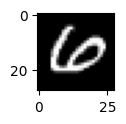

In [122]:
plt.figure(figsize=(1,1))
plt.imshow(traindata.iloc[0, 1:].values.reshape(28,28), cmap='grey')

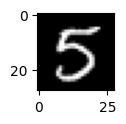

In [123]:
plt.figure(figsize=(1,1))
plt.imshow(traindata.iloc[1, 1:].values.reshape(28,28), cmap='grey')

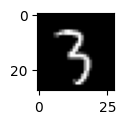

In [124]:
plt.figure(figsize=(1,1))
plt.imshow(traindata.iloc[1000, 1:].values.reshape(28,28), cmap='grey')

In [125]:
# import dense layer and sequential model

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential


In [126]:
model = Sequential()

model.add(Input(shape=(784,)))

# hidden layer
model.add(Dense(400, activation='relu', name='Hidden_layer_1'))


# last layer is output layer
model.add(Dense(10, activation='softmax', name='ouput'))
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_layer_1 (Dense)          │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ouput (Dense)                   │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,010 (1.21 MB)

 Trainable params: 318,010 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

In [128]:
xtrain = traindata.iloc[:, 1:].values/255
ytrain = traindata.iloc[:,0]
xtest = testdata.iloc[:,1:].values/255
ytest = testdata.iloc[:,0]

xtrain.shape,ytrain.shape,xtest.shape,ytest.shape

((20000, 784), (20000,), (10000, 784), (10000,))

In [134]:
model.fit(xtrain, ytrain, epochs=3, batch_size=200)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0105
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0081
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0076
